Project Title: Sunspot Analysis

Data Source: SILSO, Royal Observatory of Belgium

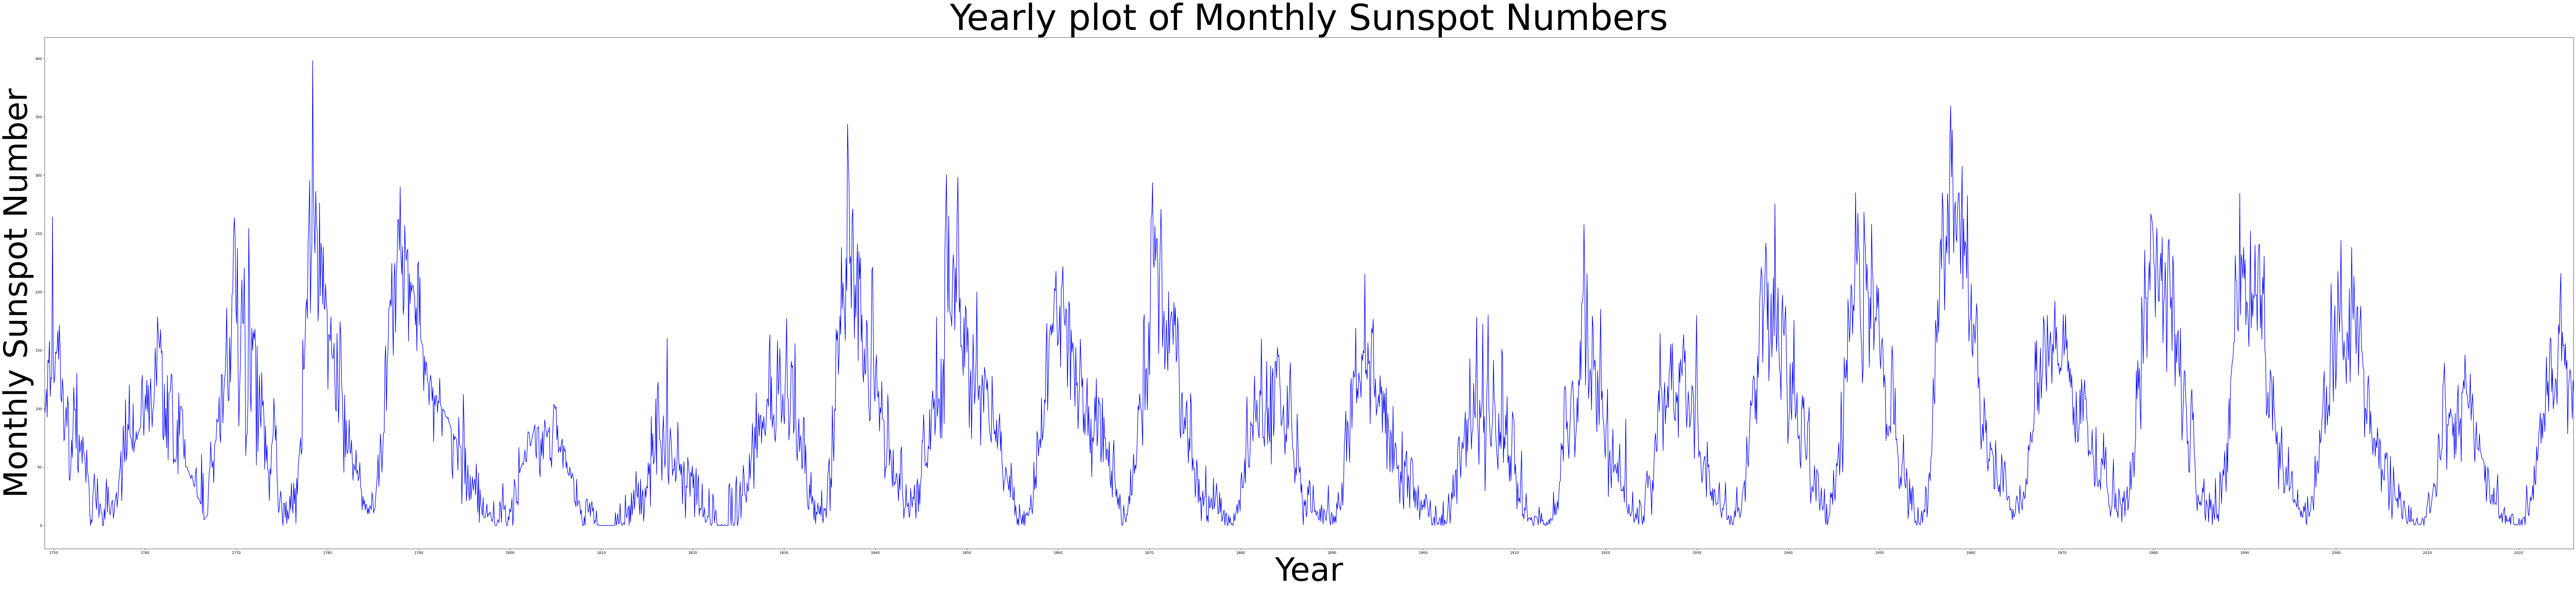

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r'SN_m_tot_V2.0.csv    ' , sep = ';' , header = None)
df.columns = ['year', 'month', 'date_decimal', 'sunspot_number', 'std_dev', 'num_observations', 'definitive']
# SILSO uses -1 as a placeholder for missing or unavailable values. 
# I have also checked for any missing or unavailable values in 'sunspot_number' column too. 
#print(df[df['sunspot_number']==-1.0])

plt.figure(figsize = (100,23))
plt.plot(df['date_decimal'],df['sunspot_number'], alpha = 1, color = 'blue')
plt.xlabel('Year', fontsize = 90)
plt.ylabel('Monthly Sunspot Number', fontsize = 90)
plt.title("Yearly plot of Monthly Sunspot Numbers", fontsize = 100)
plt.xlim(1749,2026)
plt.xticks(range(1750,2026,10))
plt.tight_layout()
plt.show()

The following observations can be drawn from the above plot: 

1. There are a total of 26 solar cycles from the year 1749 to the year 2026 which have a varying amplitude. This variation in amplitide as can be seen in plot is seemingly more in the years before 1882. The amplitude varies physically across cycles, and early measurements have higher uncertainty due to limited instrumentation.

2. We can not solely say that the older measurements are as they are because of developing technology as for example when we try to find the period of minimum solar activity it is the period in which cycles 6 and 7 took place. This period of reduced activity, from 1798 to 1833, is called Dalton minimum. It was in this period that the sun's magnetic activity weakened substantially.

3. There exists a period in mid 20th century termed as Modern Grand Maximum. It was the time of exceptionally strong activity. 

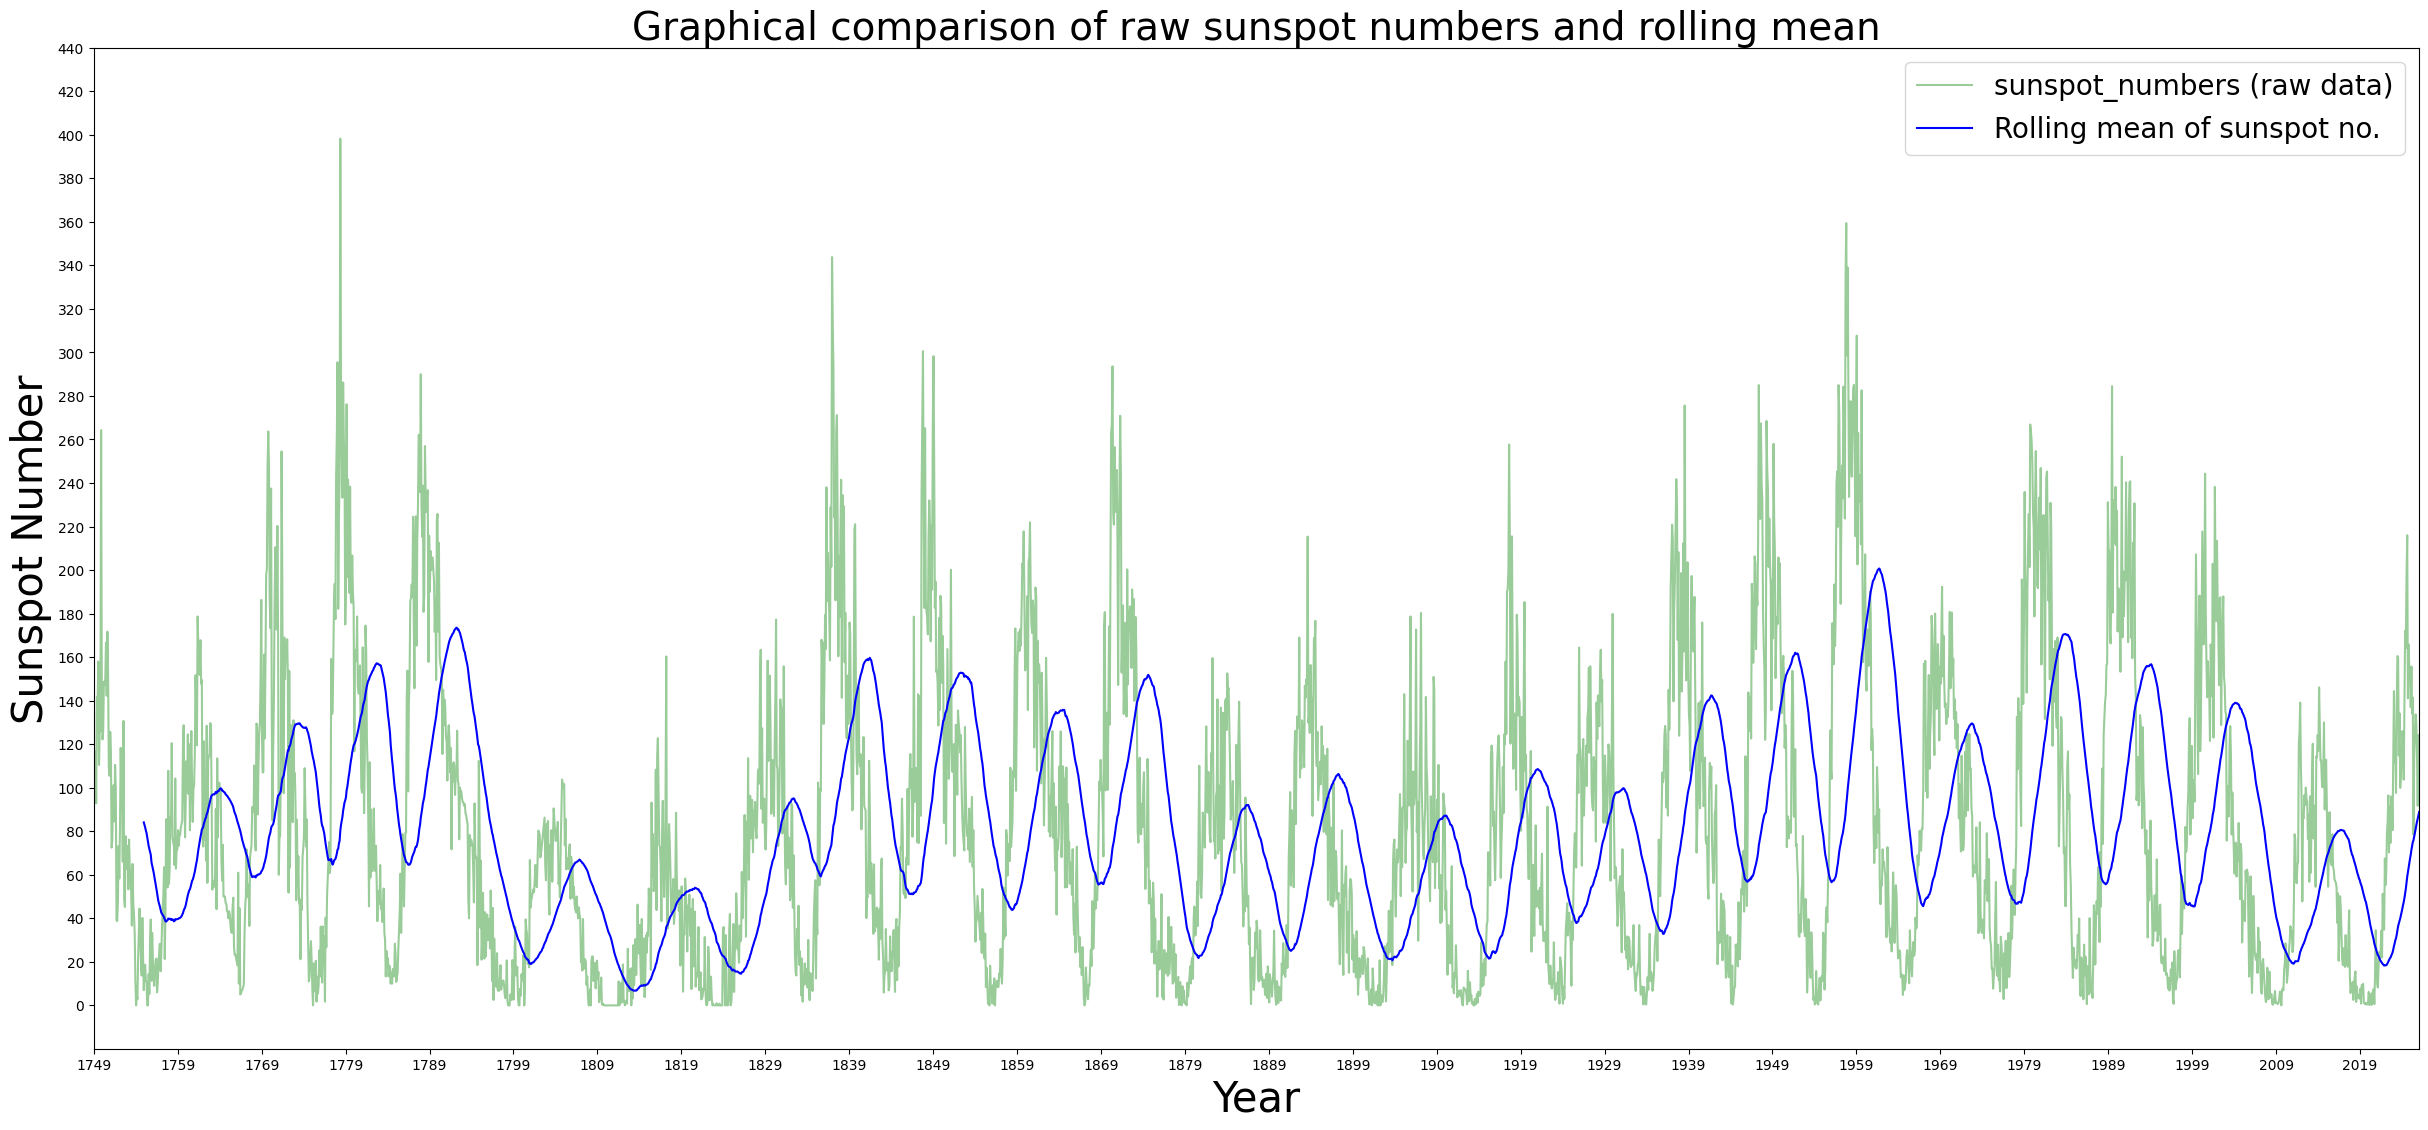

In [8]:
# Creating a 12 month rolling mean of sunspot numbers.
df['12 month rolling mean'] = df['sunspot_number'].rolling(window=72).mean()
plt.figure(figsize=(30,13))
plt.plot(df['date_decimal'],df['sunspot_number'], color= 'green', label= 'sunspot_numbers (raw data)', alpha  = 0.4)
plt.plot(df['date_decimal'],df['12 month rolling mean'], color= 'blue', label= 'Rolling mean of sunspot no.')
plt.legend(fontsize = 20, loc = 'upper right')
plt.xlabel('Year' , fontsize = 30)
plt.ylabel("Sunspot Number" , fontsize = 30)
plt.title('Graphical comparison of raw sunspot numbers and rolling mean', fontsize = 28)
plt.xticks(range(1749,2026,10))
plt.yticks(range(0,460,20))
plt.xlim(1749,2026)
plt.show()

In [9]:
#  instead of us manually looking at the plot and guessing where the peaks are, we are making Python find them automatically and precisely.
from scipy.signal import find_peaks
df_clean = df.dropna(subset=['12 month rolling mean'])
peaks , properties =find_peaks(df_clean['12 month rolling mean'].values, height=50, distance=90)
df_clean['date_decimal'].iloc[peaks]
peak_years = df_clean['date_decimal'].iloc[peaks].values
print(f'Average cycle duration: {np.diff(peak_years).mean()}')

sc25 = df[df['date_decimal'] > 2020]
print(sc25.loc[sc25['12 month rolling mean'].idxmax(), ['date_decimal', '12 month rolling mean']])
sc24 = df[(df['date_decimal'] > 2008) & (df['date_decimal'] < 2020)]
print(sc24.loc[sc24['12 month rolling mean'].idxmax(), ['date_decimal', '12 month rolling mean']])

Average cycle duration: 10.981826086956517
date_decimal             2026.371000
12 month rolling mean      93.602778
Name: 3328, dtype: float64
date_decimal             2016.7060
12 month rolling mean      80.6125
Name: 3212, dtype: float64


Below are the observations drawn from the above calculations: 

1. I have tried to calculate the average cycle length of the solar cycle. My calculated value comes out to be: 10.982 years. It is quite close to the average solar cycle length of 11 years. The difference is of almost 6.6 days. We can see from the above plots that the latest solar cycle is incomplete. This creates a problem for find_peaks function as a it identifies a point as a peak only if the values on both of its sides are lower. 
This is called edge effect and it is a genuine limitation when we work current and ongoing data. 

2. SC25 is an ongoing cycle and my data is till May 2026 and so automatic peak detection can't confirm it and hence it is not included in the data containing peak years (namely the 'peak_years' variable). 

3. On taking a profound look, we can see that the 12 month rolling mean of SC 24 came out to be 80.6125 whereas that of SC25 is 93.602778 and that too when SC25 is still ongoing. Thus, my data is giving an indication that SC25 is a much stronger cycle than SC24.
I shall make a visual comparison on SC24 and ongoing SC25 for a better understanding of the facts.

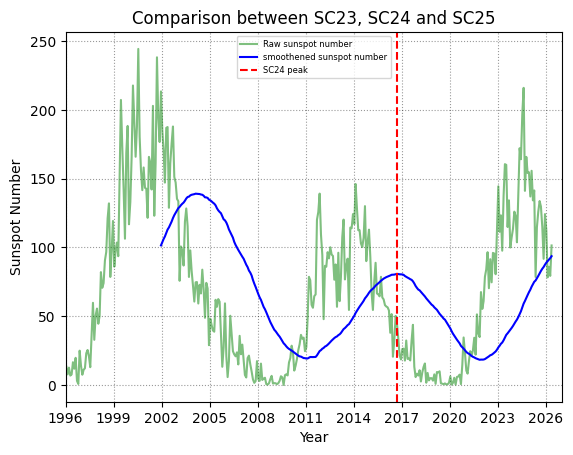

In [10]:
# Graphical comparison between SC24 and SC25.
df_recent = df[df['date_decimal']>=1996].copy() 
df_recent['Rolling'] = df_recent['sunspot_number'].rolling(72).mean()
#print(df_recent)
plt.Figure(figsize=(50,13))
plt.plot(df_recent['date_decimal'],df_recent['sunspot_number'], color = 'green', alpha = 0.5, label = 'Raw sunspot number')
plt.plot(df_recent['date_decimal'],df_recent['Rolling'], color = 'blue', label = 'smoothened sunspot number')
plt.axvline(x=2016.7, color='red', linestyle='--', label='SC24 peak')
plt.xlim(1996,2027)
plt.xticks(range(1996,2027,3))
plt.legend(loc = 'upper center', fontsize = 6)
plt.xlabel('Year')
plt.ylabel('Sunspot Number')
plt.title('Comparison between SC23, SC24 and SC25')
plt.grid(color = 'black', linestyle = ':', alpha = 0.4)
plt.show()


From this zoomed in version of the plot which showcases SC23, SC24 and a partial SC25 we can see that SC24 was a much weaker cycle. And in comparison with SC25 we can clearly see that SC25 is stronger than SC24. This is what my previous calculations suggested- 
for SC24 the rolling mean value came to be: 80.6125, whereas for SC25 it is: 93.602778 and that too when the cycle is still ongoing.

From the plot we can also see that SC23 was a very strong cycle in comparison to both SC24 and SC25. SC23 was a important cycle as it marked the transition from the strong cycles of mid 20th century to the weaker cycles of 21st century.

Dominant period: 11.10 years


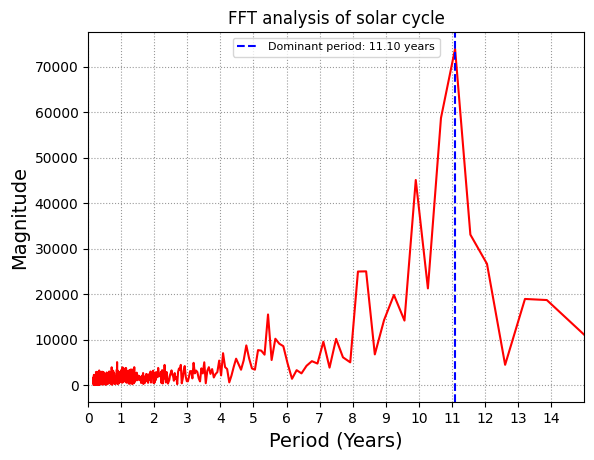

In [11]:
# We are now trying to find the Fourier Transform of the 277 year time series of monthl measurements. 
# This way we are actually confirming the ~11 year periodicity through another matheatical method.

fft_result = np.fft.fft(df['sunspot_number'].values)
freqs = np.fft.fftfreq(len(df['sunspot_number']), d=1/12)
positive = freqs>0
complex_magnitude = np.abs(fft_result)
plt.plot(1/freqs[positive], complex_magnitude[positive], color = 'red', alpha = 1)
plt.xlim(0,15)
plt.xlabel('Period (Years)',fontsize = 14)
plt.ylabel('Magnitude',fontsize= 14)
plt.xticks(range(0,15,1))
periods = 1/freqs[positive]
dominant_period = periods[np.argmax(complex_magnitude[positive])]
print(f"Dominant period: {dominant_period:.2f} years")
plt.axvline(x=dominant_period, color='blue', linestyle='--', label=f'Dominant period: {dominant_period:.2f} years')
plt.legend(loc='upper center', fontsize = 8)
plt.title('FFT analysis of solar cycle')
plt.grid(color = 'black', linestyle = ':', alpha = 0.4)
plt.show()

From the above Fourier analysis plot of the 277 year monthly solar cycle we can clearly see that the plot peaks at around the 11 year mark.Lets take a closer look at the values that we have calculated previously and what the plot shows: 
From previous results: The average cycle duration came out to be- 10.982 years
From our FFT analysis we can see that average cycle duration comes out to be- 11.10 years, as can be confirmed from graph as well.

They both are indicating that we are quite close to the actual average solar cycle (also called Schwabe cycle) duration of 11 years. The limitation in our calculations were due to the edge effect which occurs when we apply 'find_peaks' function to a data where in some parts the peak maybe undetectable. 
The reasons for FFT analysis showing value slightly greater than 11 is that it assumes that the signal we feed into it is a periodic repetition of a signal which means it assumes the frequency and amplitude to be same throughout. This is not true in the case of solar cycle as we know that it is not uniform.
Another reason for this is 'Spectral Leakage'. FFT works properly on signals which are repeated whole number times but, here in our data the signal repeats (277/11=)25.18 cycles. Due to this fractional leftover, the energy from 11 year frequency leaks into neighbouring frequencies, which is why the FFT peak is broad rather than a perfect sharp spike.